# R21 Resting-State Randomise Results

Inspect every N=27 **cluster-extent corrected** primary and secondary randomise result on MNI anatomy, summarize the corresponding dual-regression stage-2 beta for sham, RTPJ, VLPFC, and BOTH, correlate extracted brain effects with pupil/blink deltas, audit all planned contrasts including null results, and review tSNR and mean-FD boxplots. Each significant result is shown in its own interactive NiiVue viewer. TFCE results are intentionally excluded.


## 1. Verify notebook dependencies

Launch this notebook with `bash notebooks/run_randomise_notebook.sh`. IPyNiiVue uses both a Python kernel package and an AnyWidget browser extension, so installing it after JupyterLab has already started is not sufficient.


In [1]:
from pathlib import Path
import importlib.util

def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'code' / 'check_randomise_results.py').is_file():
            return candidate
    raise FileNotFoundError('Start Jupyter from the r21-rest repository or one of its subdirectories.')

PROJECT_ROOT = find_project_root()
required_imports = ('ipyniivue', 'ipywidgets', 'matplotlib', 'nibabel', 'nilearn', 'numpy', 'pandas', 'scipy')
missing = [name for name in required_imports if importlib.util.find_spec(name) is None]
if missing:
    raise RuntimeError('Missing packages: ' + ', '.join(missing) + '. Close JupyterLab and run: bash notebooks/run_randomise_notebook.sh')
print('Notebook dependencies and IPyNiiVue kernel package are available.')
print('Project root:', PROJECT_ROOT)


Notebook dependencies and IPyNiiVue kernel package are available.
Project root: /Users/tug87422/github/r21-rest


## 2. Load results and audit every planned contrast

FSL corrected-p images contain `1-p`; the notebook defines the displayed region as voxels with `1-p > 0.95`. The two tracked summary tables cover 77 primary and 98 secondary network-by-contrast jobs. The contrast audit reports every planned comparison, including those with no significant map. Each network/contrast is interpreted as an individual hypothesis. Following Rubin's inference-based framework, no blanket alpha adjustment is applied merely because 175 jobs were run; an adjustment would be relevant only for a disjunctive claim that at least one effect exists somewhere in that collection.


In [2]:
import json

import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import datasets, image, plotting
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display, Markdown
from ipyniivue import NiiVue

CORRP_THRESHOLD = 0.95
CONDITION_ORDER = ['sham', 'rtpj', 'vlpfc', 'both']
CONDITION_LABELS = ['Sham', 'RTPJ', 'VLPFC', 'BOTH']
NETWORK_LABELS = {
    'dmn': 'default mode network (DMN)',
    'ecn': 'executive control network (ECN)',
    'right-fpn': 'right frontoparietal network',
    'left-fpn': 'left frontoparietal network',
    'primary-visual': 'primary visual network',
    'occipital-pole': 'occipital-pole visual network',
    'lateral-visual': 'lateral visual network',
    'primary-visual-lateral-visual': 'combined primary/lateral visual component',
    'sensorimotor': 'sensorimotor network',
    'auditory': 'auditory network',
}
ANALYSIS_LABELS = {'0': 'data-derived ICA, automatic dimensionality', '20': 'data-derived ICA, 20 components', 'smith09': 'direct Smith09 RSN map'}
SUMMARY_DIR = PROJECT_ROOT / 'derivatives' / 'fsl' / 'randomise_summary'
SUMMARY_SPECS = [
    ('primary', SUMMARY_DIR / 'task-rest_randomise_peak_summary.tsv'),
    ('secondary', SUMMARY_DIR / 'task-rest_desc-SecondaryNetworks_randomise_peak_summary.tsv'),
]
missing_summaries = [str(path) for _, path in SUMMARY_SPECS if not path.is_file()]
if missing_summaries:
    raise FileNotFoundError('Missing randomise summaries: ' + ', '.join(missing_summaries))

result_tables = []
for family, path in SUMMARY_SPECS:
    table = pd.read_csv(path, sep='\t', dtype=str).fillna('')
    table['family'] = family
    table['summary_file'] = str(path.relative_to(PROJECT_ROOT))
    result_tables.append(table)
results = pd.concat(result_tables, ignore_index=True)

if 'roi_values_tsv' not in results.columns:
    raise RuntimeError('Rerun code/check_randomise_results.py on the Linux box and push the generated ROI-value TSVs.')
significant = results.loc[(results['inference'] == 'cluster-extent') & (results['peak_gt_threshold'] == 'true') & (results['status'] == 'ok')].copy()
contrast_terms = {
    'both-minus-sham': ('BOTH', 'sham'),
    'both-minus-rtpj': ('BOTH', 'RTPJ'),
    'both-minus-vlpfc': ('BOTH', 'VLPFC'),
    'rtpj-minus-vlpfc': ('RTPJ', 'VLPFC'),
    'rtpj-minus-sham': ('RTPJ', 'sham'),
    'vlpfc-minus-sham': ('VLPFC', 'sham'),
    'both-minus-mean-rtpj-vlpfc': ('BOTH', 'average(RTPJ, VLPFC)'),
}
def signed_effect(row):
    first, second = contrast_terms[row['condition_contrast']]
    if row['direction'] == 'negative':
        first, second = second, first
    return f'{first} > {second}'

significant['effect'] = significant.apply(signed_effect, axis=1)
significant['peak_fwe_p'] = 1.0 - significant['peak_corrp'].astype(float)
significant['family'] = pd.Categorical(significant['family'], ['primary', 'secondary'], ordered=True)
significant = significant.sort_values(['family', 'peak_fwe_p', 'analysis', 'network']).reset_index(drop=True)
if significant.empty:
    raise RuntimeError('The summary contains no complete cluster-extent maps with peak 1-p > 0.95.')
if (significant['roi_values_tsv'].str.strip() == '').any():
    raise RuntimeError('Portable ROI values are missing. Rerun code/check_randomise_results.py on Linux, then commit and push derivatives/fsl/randomise_summary.')
significant['analysis_description'] = significant['analysis'].map(ANALYSIS_LABELS)
significant['network_description'] = significant['network'].map(NETWORK_LABELS).fillna(significant['network'])
summary_table = significant[['family', 'analysis_description', 'network_description', 'component', 'effect', 'peak_fwe_p']].copy()
summary_table.columns = ['Family', 'Analysis', 'Network', 'Map/component', 'Signed effect', 'Peak FWE-corrected p']
summary_table['Family'] = summary_table['Family'].astype(str).str.title()
summary_table.insert(0, 'Result', range(1, len(summary_table) + 1))
primary_count = int((significant['family'] == 'primary').sum())
secondary_count = int((significant['family'] == 'secondary').sum())
print(f'Cluster-extent results available: {len(significant)} ({primary_count} primary; {secondary_count} secondary)')
print('Across-job interpretation follows separate individual hypotheses; no global alpha adjustment is applied.')
display(summary_table.style.format({'Peak FWE-corrected p': '{:.4f}'}).hide(axis='index'))

contrast_labels = {
    'both-minus-sham': 'BOTH − sham',
    'both-minus-rtpj': 'BOTH − RTPJ',
    'both-minus-vlpfc': 'BOTH − VLPFC',
    'rtpj-minus-vlpfc': 'RTPJ − VLPFC',
    'rtpj-minus-sham': 'RTPJ − sham',
    'vlpfc-minus-sham': 'VLPFC − sham',
    'both-minus-mean-rtpj-vlpfc': 'BOTH − average(RTPJ, VLPFC)',
}
cluster_results = results.loc[(results['inference'] == 'cluster-extent') & (results['status'] == 'ok')].copy()
cluster_results['peak_corrp_numeric'] = pd.to_numeric(cluster_results['peak_corrp'], errors='coerce')
cluster_results['significant_direction'] = cluster_results['peak_gt_threshold'].eq('true')
contrast_audit = cluster_results.groupby('condition_contrast', sort=False).agg(
    tested_directions=('condition_contrast', 'size'),
    significant_directions=('significant_direction', 'sum'),
    best_corrp=('peak_corrp_numeric', 'max'),
).reindex(contrast_labels)
contrast_audit['Jobs'] = contrast_audit['tested_directions'] // 2
contrast_audit['Best corrected p'] = 1.0 - contrast_audit['best_corrp']
contrast_audit.insert(0, 'Planned contrast', [contrast_labels[index] for index in contrast_audit.index])
contrast_audit = contrast_audit[['Planned contrast', 'Jobs', 'significant_directions', 'Best corrected p']]
contrast_audit.columns = ['Planned contrast', 'Jobs', 'Significant directions', 'Best corrected p']
display(Markdown('### Complete planned-contrast audit'))
display(contrast_audit.style.format({'Best corrected p': '{:.4f}'}).hide(axis='index'))
both_single = contrast_audit.loc['both-minus-mean-rtpj-vlpfc']
print(
    'BOTH > single-site mean: '
    f"{int(both_single['Significant directions'])} significant directions; "
    f"best corrected p = {both_single['Best corrected p']:.4f}."
)


Cluster-extent results available: 12 (3 primary; 9 secondary)
Across-job interpretation follows separate individual hypotheses; no global alpha adjustment is applied.


Result,Family,Analysis,Network,Map/component,Signed effect,Peak FWE-corrected p
1,Primary,"data-derived ICA, automatic dimensionality",default mode network (DMN),23,VLPFC > RTPJ,0.0066
2,Primary,direct Smith09 RSN map,default mode network (DMN),4,VLPFC > RTPJ,0.0156
3,Primary,direct Smith09 RSN map,executive control network (ECN),8,RTPJ > BOTH,0.0200
4,Secondary,"data-derived ICA, 20 components",occipital-pole visual network,17,sham > BOTH,0.0064
5,Secondary,direct Smith09 RSN map,lateral visual network,3,VLPFC > BOTH,0.0086
6,Secondary,"data-derived ICA, 20 components",combined primary/lateral visual component,6,BOTH > VLPFC,0.0194
7,Secondary,direct Smith09 RSN map,sensorimotor network,6,BOTH > RTPJ,0.0204
8,Secondary,"data-derived ICA, automatic dimensionality",sensorimotor network,22,VLPFC > sham,0.0272
9,Secondary,"data-derived ICA, 20 components",sensorimotor network,3,RTPJ > sham,0.0366
10,Secondary,direct Smith09 RSN map,lateral visual network,3,VLPFC > RTPJ,0.0382


### Complete planned-contrast audit

Planned contrast,Jobs,Significant directions,Best corrected p
BOTH − sham,25,2,0.0064
BOTH − RTPJ,25,2,0.0200
BOTH − VLPFC,25,2,0.0086
RTPJ − VLPFC,25,3,0.0066
RTPJ − sham,25,2,0.0366
VLPFC − sham,25,1,0.0272
"BOTH − average(RTPJ, VLPFC)",25,0,0.0506


BOTH > single-site mean: 0 significant directions; best corrected p = 0.0506.


## 3. Define visualization and ROI-summary helpers


In [3]:
def project_path(value):
    path = Path(value)
    return path if path.is_absolute() else PROJECT_ROOT / path

def result_image(row):
    copied = str(row.get('copied_image', '')).strip()
    source = copied or str(row['corrp_file']).strip()
    path = project_path(source)
    if not path.is_file():
        raise FileNotFoundError(path)
    return path

def result_label(row):
    return f"{row['effect']} in the {row['network_description']}"

def result_sidecar(row):
    path = project_path(row['copied_sidecar'])
    return json.loads(path.read_text()) if path.is_file() else {}

def extract_condition_values(row_index):
    row = significant.loc[row_index]
    corrp_img = nib.load(str(result_image(row)))
    corrp_data = np.asarray(corrp_img.dataobj)
    roi = np.isfinite(corrp_data) & (corrp_data > CORRP_THRESHOLD)
    if not roi.any():
        raise ValueError('Selected corrected-p map has no voxels above the threshold.')

    values_path = project_path(row['roi_values_tsv'])
    if not values_path.is_file():
        raise FileNotFoundError(f'Portable ROI-value table is not tracked locally: {values_path}')
    values = pd.read_csv(values_path, sep='\t', dtype={'participant': str, 'condition': str})
    required = {'participant', 'condition', 'stage2_beta'}
    if not required.issubset(values.columns):
        raise ValueError(f'{values_path} is missing columns: {sorted(required.difference(values.columns))}')
    values['stage2_beta'] = pd.to_numeric(values['stage2_beta'], errors='raise')
    values['condition'] = values['condition'].str.lower()
    counts = values.groupby('participant')['condition'].nunique()
    complete = counts[counts == 4].index
    values = values.loc[values['participant'].isin(complete)].copy()
    values['condition'] = pd.Categorical(values['condition'], CONDITION_ORDER, ordered=True)
    return values, corrp_img, roi

def plot_condition_bars(values, title):
    summary = values.groupby('condition', observed=False)['stage2_beta'].agg(['mean', 'sem', 'count']).reindex(CONDITION_ORDER)
    fig, ax = plt.subplots(figsize=(7.5, 4.6))
    colors = ['#8A8F98', '#2878B5', '#D95F59', '#3A9D6F']
    positions = np.arange(len(CONDITION_ORDER))
    ax.bar(positions, summary['mean'], yerr=summary['sem'], capsize=5, color=colors, edgecolor='#222222', linewidth=0.8, alpha=0.86)
    ax.set_xticks(positions, CONDITION_LABELS)
    ax.axhline(0, color='#555555', linewidth=0.8)
    ax.set_ylabel('Dual-regression stage-2 beta\n(mean ± SEM)')
    ax.set_title(title, fontsize=12, pad=12)
    ax.text(0.99, 0.02, f"n = {int(summary['count'].min())} participants", transform=ax.transAxes, ha='right', va='bottom', color='#555555', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    display(fig)
    plt.close(fig)
    return summary

## 4. All primary and secondary significant results

Each warm-colored overlay contains only voxels with cluster-extent FWE-corrected `1-p > 0.95` (corrected `p < 0.05`). The overlay encodes corrected significance, not connectivity magnitude. Use the NiiVue controls to change slice position, orientation, opacity, and rendering mode. A static anatomical view follows each NiiVue widget so saved notebooks remain interpretable on GitHub.


### Result 1: VLPFC > RTPJ in the default mode network (DMN)

- **Analysis family:** Primary.
- **Network definition:** data-derived ICA, automatic dimensionality, component 23.
- **Tested contrast:** `rtpj-minus-vlpfc`, C2 (negative); this is **VLPFC > RTPJ**.
- **Inference:** one-sample randomise, 5,000 permutations, cluster-forming *t* = 3.1.
- **Corrected result:** peak FWE-corrected *p* = 0.0066; 9 suprathreshold voxels.
- **Bar plot:** mean stage-2 beta ± SEM across 27 participants within the displayed cluster.

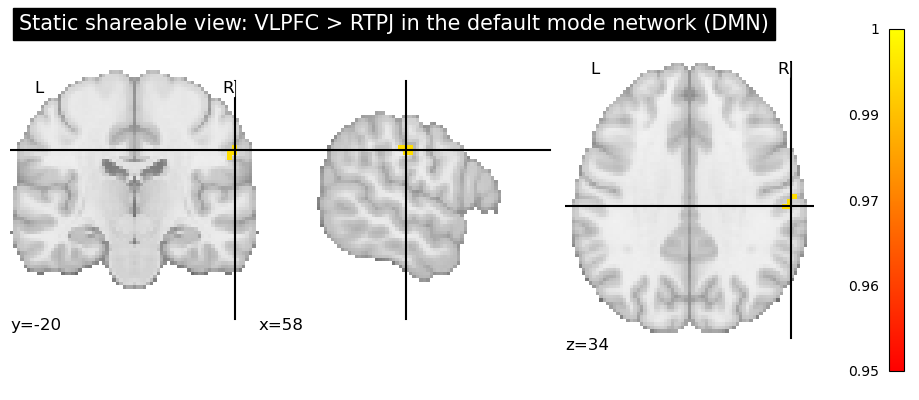

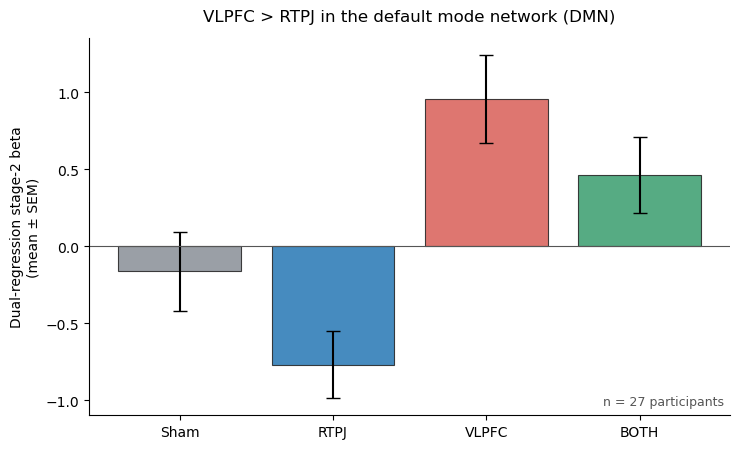

### Result 2: VLPFC > RTPJ in the default mode network (DMN)

- **Analysis family:** Primary.
- **Network definition:** direct Smith09 RSN map, map 4.
- **Tested contrast:** `rtpj-minus-vlpfc`, C2 (negative); this is **VLPFC > RTPJ**.
- **Inference:** one-sample randomise, 5,000 permutations, cluster-forming *t* = 3.1.
- **Corrected result:** peak FWE-corrected *p* = 0.0156; 15 suprathreshold voxels.
- **Bar plot:** mean stage-2 beta ± SEM across 27 participants within the displayed cluster.

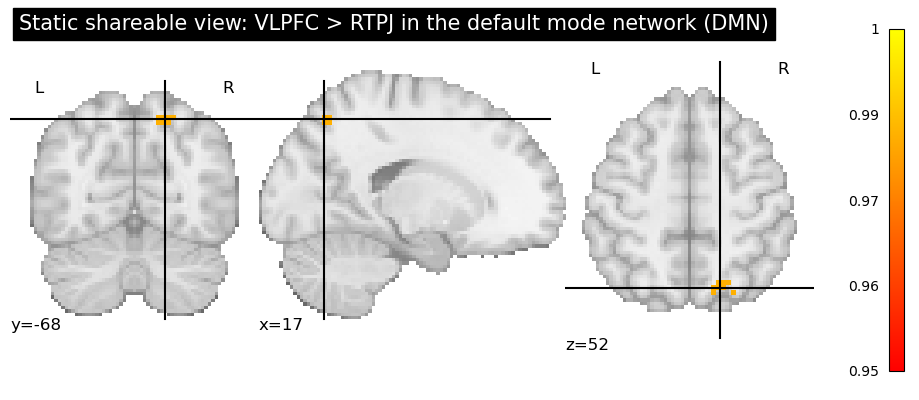

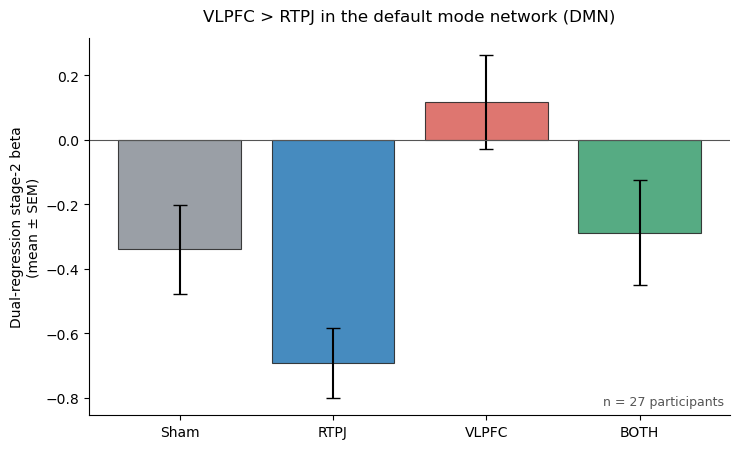

### Result 3: RTPJ > BOTH in the executive control network (ECN)

- **Analysis family:** Primary.
- **Network definition:** direct Smith09 RSN map, map 8.
- **Tested contrast:** `both-minus-rtpj`, C2 (negative); this is **RTPJ > BOTH**.
- **Inference:** one-sample randomise, 5,000 permutations, cluster-forming *t* = 3.1.
- **Corrected result:** peak FWE-corrected *p* = 0.0200; 15 suprathreshold voxels.
- **Bar plot:** mean stage-2 beta ± SEM across 27 participants within the displayed cluster.

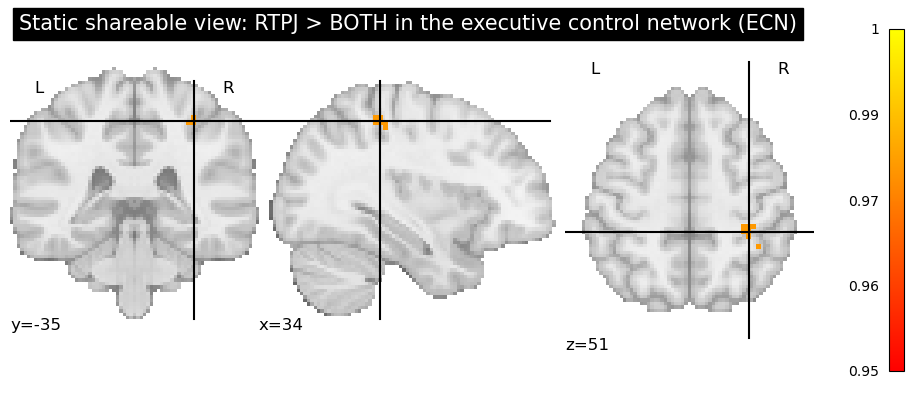

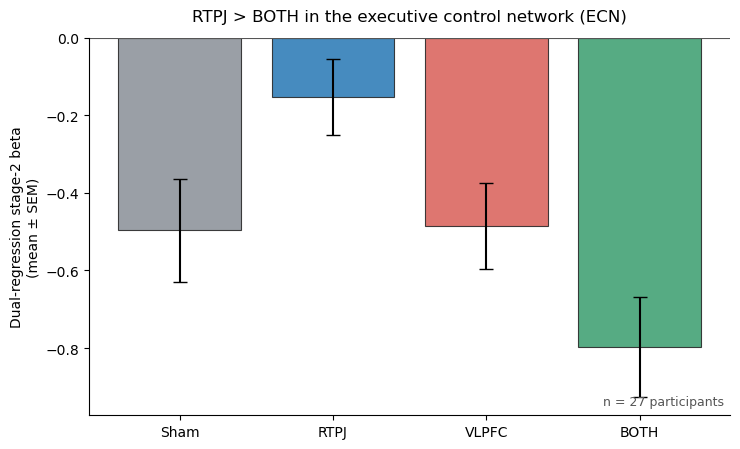

### Result 4: sham > BOTH in the occipital-pole visual network

- **Analysis family:** Secondary.
- **Network definition:** data-derived ICA, 20 components, component 17.
- **Tested contrast:** `both-minus-sham`, C2 (negative); this is **sham > BOTH**.
- **Inference:** one-sample randomise, 5,000 permutations, cluster-forming *t* = 3.1.
- **Corrected result:** peak FWE-corrected *p* = 0.0064; 13 suprathreshold voxels.
- **Bar plot:** mean stage-2 beta ± SEM across 27 participants within the displayed cluster.

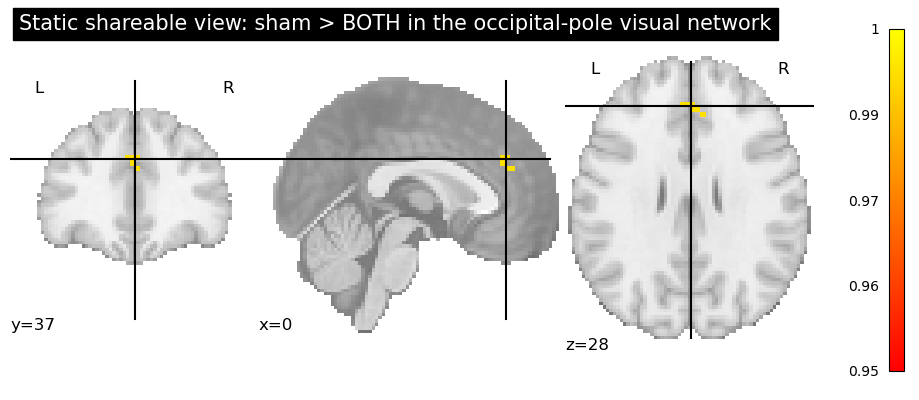

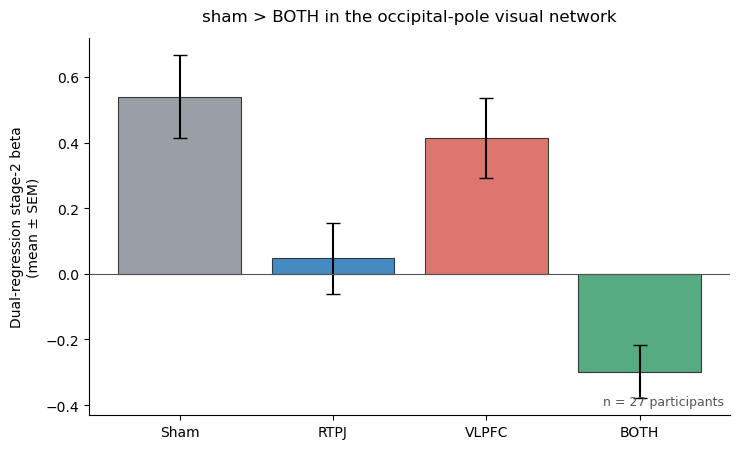

### Result 5: VLPFC > BOTH in the lateral visual network

- **Analysis family:** Secondary.
- **Network definition:** direct Smith09 RSN map, map 3.
- **Tested contrast:** `both-minus-vlpfc`, C2 (negative); this is **VLPFC > BOTH**.
- **Inference:** one-sample randomise, 5,000 permutations, cluster-forming *t* = 3.1.
- **Corrected result:** peak FWE-corrected *p* = 0.0086; 30 suprathreshold voxels.
- **Bar plot:** mean stage-2 beta ± SEM across 27 participants within the displayed cluster.

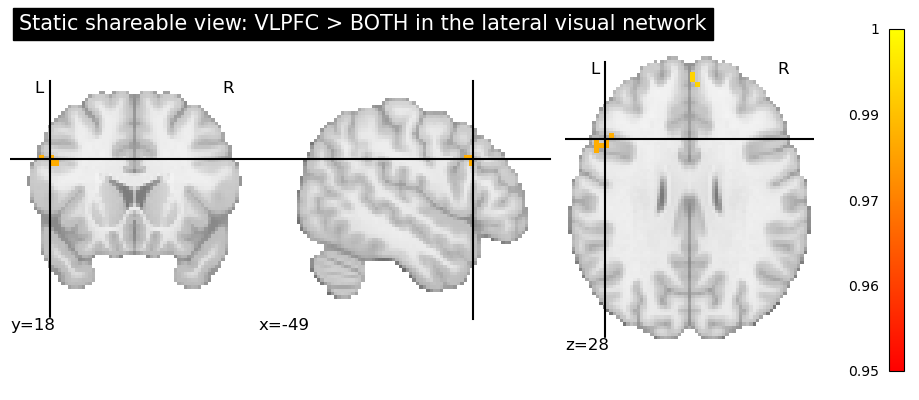

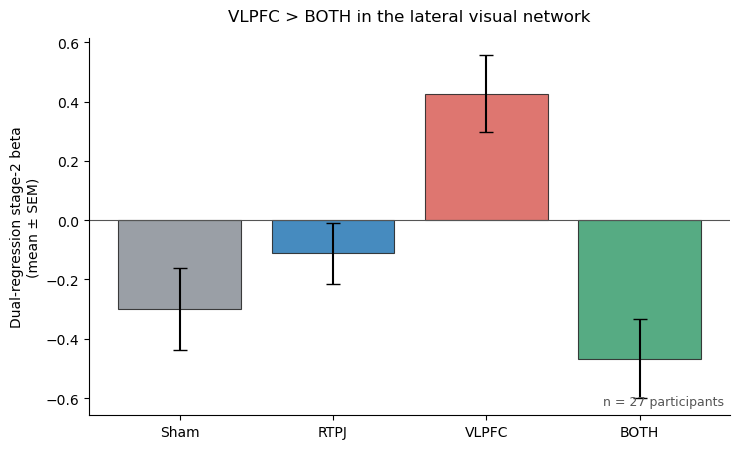

### Result 6: BOTH > VLPFC in the combined primary/lateral visual component

- **Analysis family:** Secondary.
- **Network definition:** data-derived ICA, 20 components, component 6.
- **Tested contrast:** `both-minus-vlpfc`, C1 (positive); this is **BOTH > VLPFC**.
- **Inference:** one-sample randomise, 5,000 permutations, cluster-forming *t* = 3.1.
- **Corrected result:** peak FWE-corrected *p* = 0.0194; 11 suprathreshold voxels.
- **Bar plot:** mean stage-2 beta ± SEM across 27 participants within the displayed cluster.

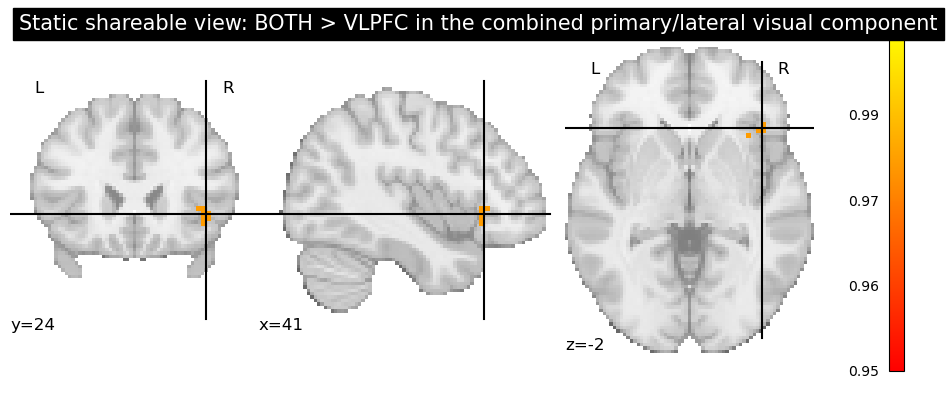

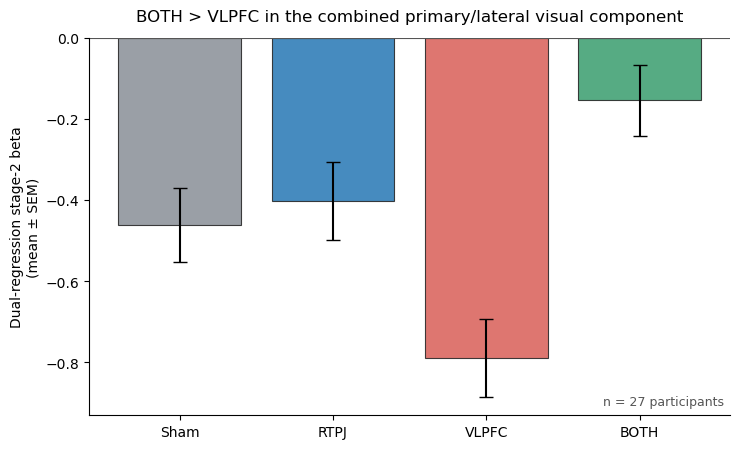

### Result 7: BOTH > RTPJ in the sensorimotor network

- **Analysis family:** Secondary.
- **Network definition:** direct Smith09 RSN map, map 6.
- **Tested contrast:** `both-minus-rtpj`, C1 (positive); this is **BOTH > RTPJ**.
- **Inference:** one-sample randomise, 5,000 permutations, cluster-forming *t* = 3.1.
- **Corrected result:** peak FWE-corrected *p* = 0.0204; 14 suprathreshold voxels.
- **Bar plot:** mean stage-2 beta ± SEM across 27 participants within the displayed cluster.

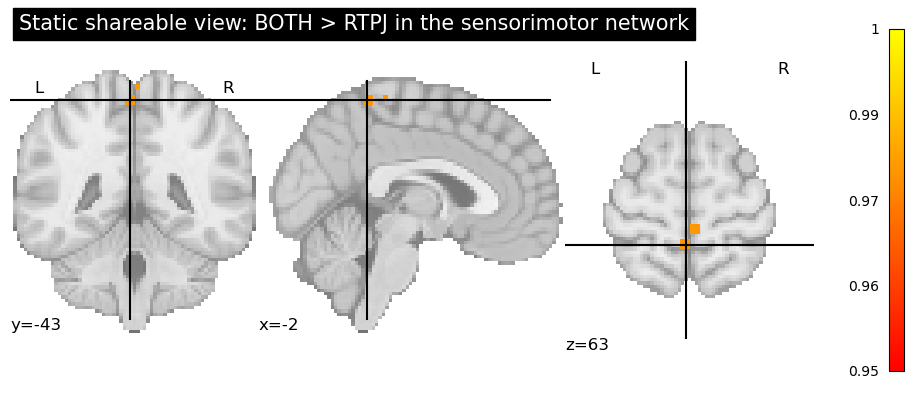

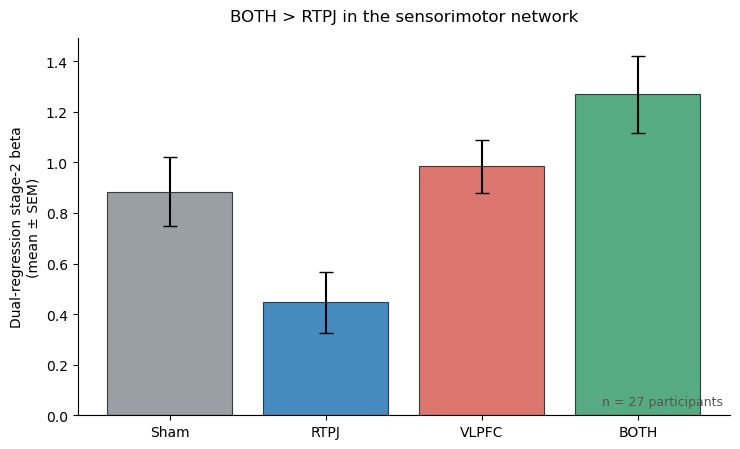

### Result 8: VLPFC > sham in the sensorimotor network

- **Analysis family:** Secondary.
- **Network definition:** data-derived ICA, automatic dimensionality, component 22.
- **Tested contrast:** `vlpfc-minus-sham`, C1 (positive); this is **VLPFC > sham**.
- **Inference:** one-sample randomise, 5,000 permutations, cluster-forming *t* = 3.1.
- **Corrected result:** peak FWE-corrected *p* = 0.0272; 7 suprathreshold voxels.
- **Bar plot:** mean stage-2 beta ± SEM across 27 participants within the displayed cluster.

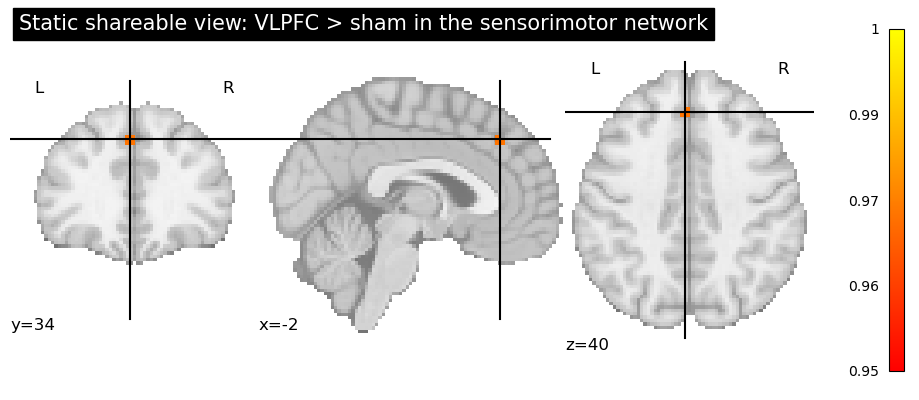

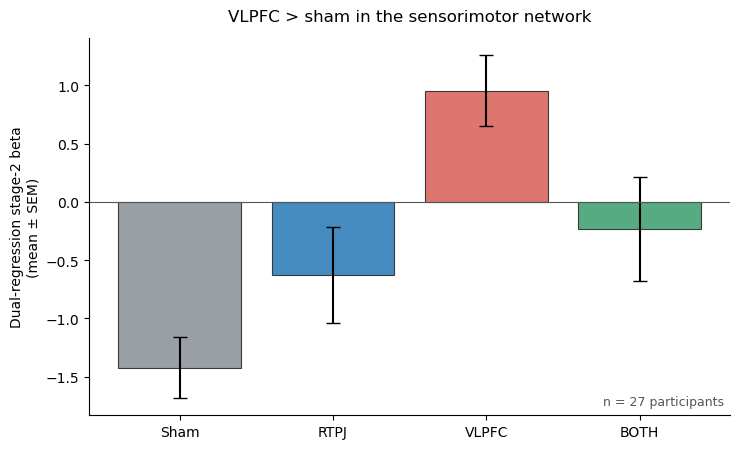

### Result 9: RTPJ > sham in the sensorimotor network

- **Analysis family:** Secondary.
- **Network definition:** data-derived ICA, 20 components, component 3.
- **Tested contrast:** `rtpj-minus-sham`, C1 (positive); this is **RTPJ > sham**.
- **Inference:** one-sample randomise, 5,000 permutations, cluster-forming *t* = 3.1.
- **Corrected result:** peak FWE-corrected *p* = 0.0366; 9 suprathreshold voxels.
- **Bar plot:** mean stage-2 beta ± SEM across 27 participants within the displayed cluster.

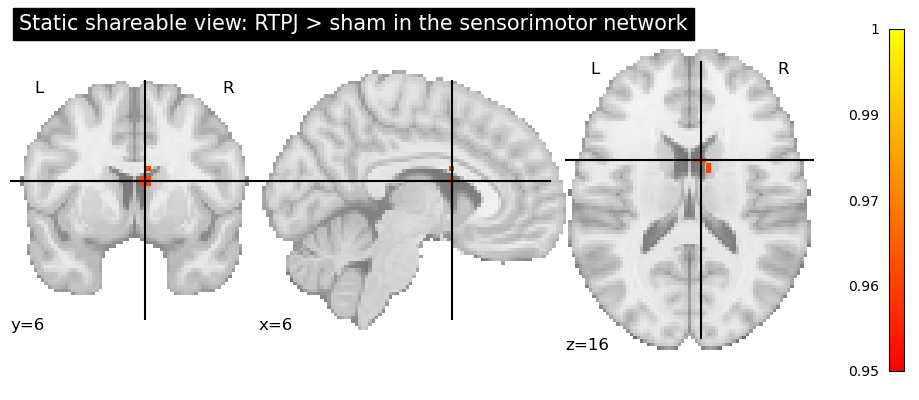

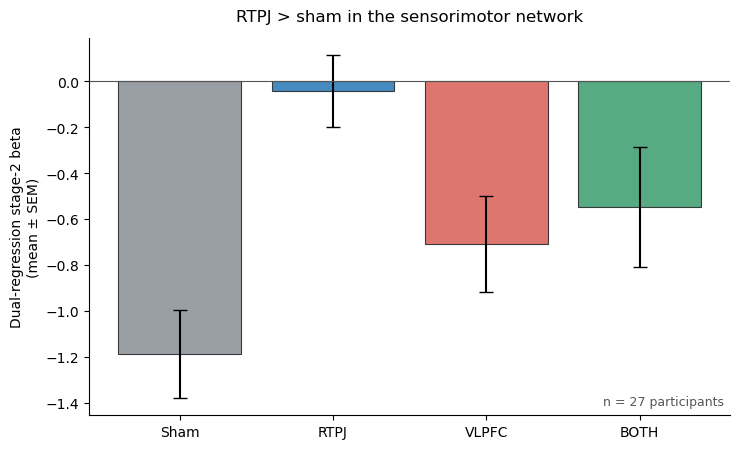

### Result 10: VLPFC > RTPJ in the lateral visual network

- **Analysis family:** Secondary.
- **Network definition:** direct Smith09 RSN map, map 3.
- **Tested contrast:** `rtpj-minus-vlpfc`, C2 (negative); this is **VLPFC > RTPJ**.
- **Inference:** one-sample randomise, 5,000 permutations, cluster-forming *t* = 3.1.
- **Corrected result:** peak FWE-corrected *p* = 0.0382; 12 suprathreshold voxels.
- **Bar plot:** mean stage-2 beta ± SEM across 27 participants within the displayed cluster.

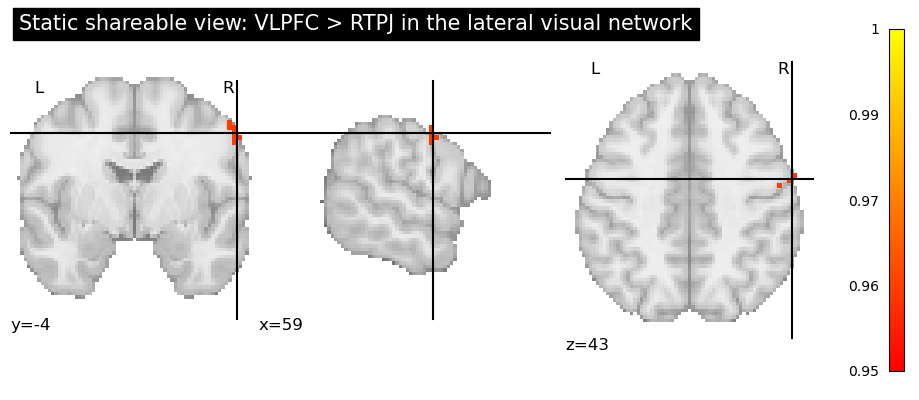

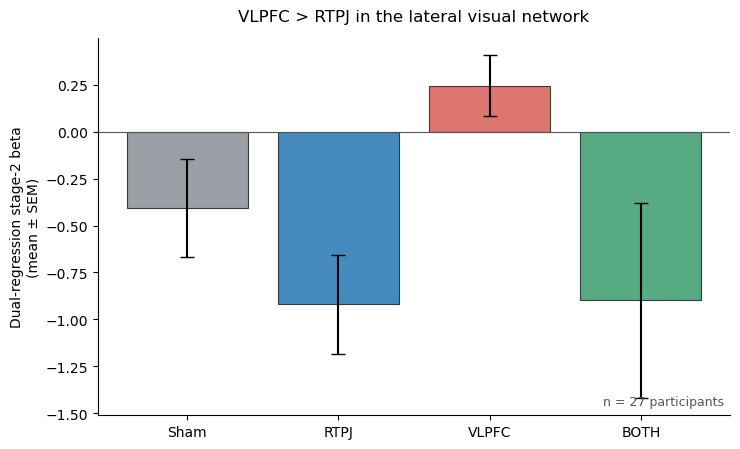

### Result 11: RTPJ > sham in the auditory network

- **Analysis family:** Secondary.
- **Network definition:** data-derived ICA, automatic dimensionality, component 55.
- **Tested contrast:** `rtpj-minus-sham`, C1 (positive); this is **RTPJ > sham**.
- **Inference:** one-sample randomise, 5,000 permutations, cluster-forming *t* = 3.1.
- **Corrected result:** peak FWE-corrected *p* = 0.0390; 7 suprathreshold voxels.
- **Bar plot:** mean stage-2 beta ± SEM across 27 participants within the displayed cluster.

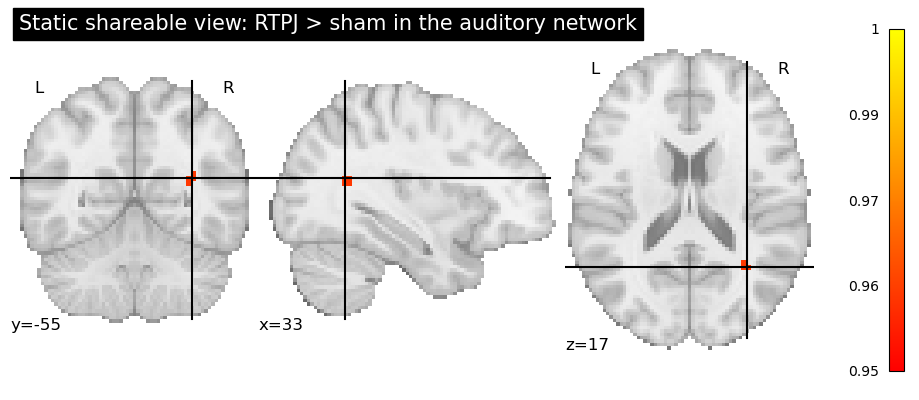

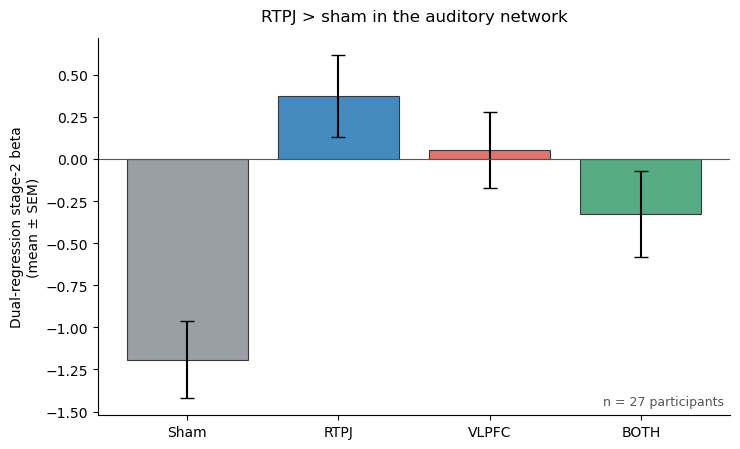

### Result 12: BOTH > sham in the sensorimotor network

- **Analysis family:** Secondary.
- **Network definition:** direct Smith09 RSN map, map 6.
- **Tested contrast:** `both-minus-sham`, C1 (positive); this is **BOTH > sham**.
- **Inference:** one-sample randomise, 5,000 permutations, cluster-forming *t* = 3.1.
- **Corrected result:** peak FWE-corrected *p* = 0.0470; 12 suprathreshold voxels.
- **Bar plot:** mean stage-2 beta ± SEM across 27 participants within the displayed cluster.

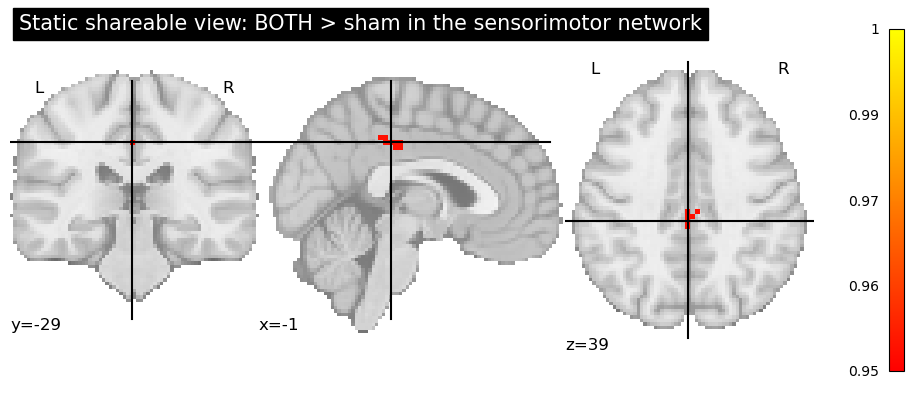

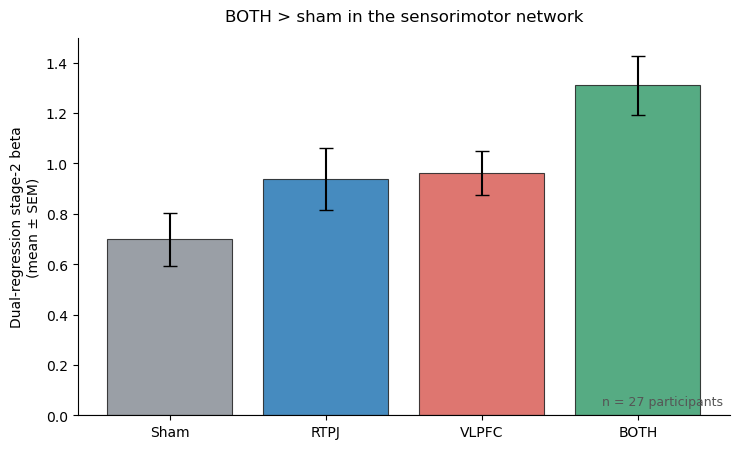

In [5]:
CACHE_DIR = PROJECT_ROOT / 'derivatives' / 'fsl' / 'randomise_summary' / '.notebook_cache'
CACHE_DIR.mkdir(exist_ok=True)
mni_img = datasets.load_mni152_template(resolution=2)
mni_path = Path(mni_img.get_filename()) if mni_img.get_filename() else CACHE_DIR / 'MNI152_T1_2mm.nii.gz'
if not mni_path.is_file():
    nib.save(mni_img, mni_path)

def thresholded_map_path(row, corrp_img, roi):
    source = result_image(row)
    destination = CACHE_DIR / source.name.replace('_stat-corrp_statmap.nii.gz', '_desc-thresholded_statmap.nii.gz')
    thresholded = image.new_img_like(corrp_img, np.where(roi, np.asarray(corrp_img.dataobj), 0.0), copy_header=True)
    nib.save(thresholded, destination)
    return destination

for result_number, (row_index, row) in enumerate(significant.iterrows(), start=1):
    values, corrp_img, roi = extract_condition_values(row_index)
    sidecar = result_sidecar(row)
    corrected_p = 1.0 - float(row['peak_corrp'])
    n_participants = values['participant'].nunique()
    map_label = f"map {int(row['component'])}" if row['analysis'] == 'smith09' else f"component {int(row['component'])}"
    display(Markdown(
        f"### Result {result_number}: {result_label(row)}\n\n"
        f"- **Analysis family:** {str(row['family']).title()}.\n"
        f"- **Network definition:** {row['analysis_description']}, {map_label}.\n"
        f"- **Tested contrast:** `{row['condition_contrast']}`, {row['design_contrast']} ({row['direction']}); this is **{row['effect']}**.\n"
        f"- **Inference:** one-sample randomise, {int(sidecar.get('NumberOfPermutations', 5000)):,} permutations, cluster-forming *t* = {float(sidecar.get('ClusterFormingTThreshold', 3.1)):.1f}.\n"
        f"- **Corrected result:** peak FWE-corrected *p* = {corrected_p:.4f}; {int(roi.sum())} suprathreshold voxels.\n"
        f"- **Bar plot:** mean stage-2 beta ± SEM across {n_participants} participants within the displayed cluster."
    ))
    overlay_path = thresholded_map_path(row, corrp_img, roi)
    viewer = NiiVue()
    viewer.load_volumes([
        {'path': str(mni_path), 'name': 'MNI152 T1 2 mm', 'colormap': 'gray', 'opacity': 1.0},
        {'path': str(overlay_path), 'name': row['effect'], 'colormap': 'red', 'opacity': 0.80, 'cal_min': CORRP_THRESHOLD, 'cal_max': 1.0},
    ])
    display(viewer)
    static_figure = plt.figure(figsize=(9, 3.8))
    plotting.plot_stat_map(
        str(overlay_path), bg_img=mni_img, threshold=CORRP_THRESHOLD,
        display_mode='ortho', cmap='autumn', colorbar=True, black_bg=False,
        vmin=CORRP_THRESHOLD, vmax=1.0,
        title=f'Static shareable view: {result_label(row)}',
        figure=static_figure,
    )
    display(static_figure)
    plt.close(static_figure)
    plot_condition_bars(values, result_label(row))

## 5. Pupil/blink correlations with extracted brain effects

For each significant cluster, compute the participant-level brain contrast from the tracked stage-2 beta table using the same signed direction as the randomise result. Join that brain contrast to the matching signed pupil and blink deltas within the primary N=27 subject scope. Pupil and blink correlations are pairwise-complete, so missing pupil values do not remove otherwise usable blink data.


In [ ]:
COVARIATE_PATH = PROJECT_ROOT / 'derivatives' / 'qc' / 'task-rest_group_covariates.tsv'
if not COVARIATE_PATH.is_file():
    raise FileNotFoundError(COVARIATE_PATH)

covariates = pd.read_csv(COVARIATE_PATH, sep='\t', dtype={'participant': str, 'contrast': str}).fillna('')
covariates['complete'] = covariates['complete'].astype(str).str.lower()
PRIMARY_CONTRASTS = list(contrast_labels)
complete_matrix = (
    covariates.pivot(index='participant', columns='contrast', values='complete')
    .reindex(columns=PRIMARY_CONTRASTS)
)
primary_participants = sorted(complete_matrix.index[complete_matrix.eq('true').all(axis=1)].tolist())
if len(primary_participants) != 27:
    raise ValueError(f'Expected the primary analysis subject scope to be N=27; found N={len(primary_participants)}')

CONTRAST_WEIGHTS = {
    'both-minus-sham': {'both': 1.0, 'sham': -1.0},
    'both-minus-rtpj': {'both': 1.0, 'rtpj': -1.0},
    'both-minus-vlpfc': {'both': 1.0, 'vlpfc': -1.0},
    'rtpj-minus-vlpfc': {'rtpj': 1.0, 'vlpfc': -1.0},
    'rtpj-minus-sham': {'rtpj': 1.0, 'sham': -1.0},
    'vlpfc-minus-sham': {'vlpfc': 1.0, 'sham': -1.0},
    'both-minus-mean-rtpj-vlpfc': {'both': 1.0, 'rtpj': -0.5, 'vlpfc': -0.5},
}

def signed_weights(row):
    multiplier = -1.0 if row['direction'] == 'negative' else 1.0
    return {
        condition: multiplier * weight
        for condition, weight in CONTRAST_WEIGHTS[row['condition_contrast']].items()
    }

def weighted_subject_delta(values, weights, value_column, output_column):
    pivot = values.pivot_table(index='participant', columns='condition', values=value_column, aggfunc='mean')
    missing_conditions = sorted(set(weights).difference(pivot.columns))
    if missing_conditions:
        raise ValueError(f'Missing condition columns for {output_column}: {missing_conditions}')
    delta = sum(pivot[condition].astype(float) * weight for condition, weight in weights.items())
    return delta.rename(output_column).reset_index()

def brain_effect_for_result(row):
    values_path = project_path(row['roi_values_tsv'])
    values = pd.read_csv(values_path, sep='\t', dtype={'participant': str, 'condition': str})
    values['condition'] = values['condition'].str.lower()
    values['stage2_beta'] = pd.to_numeric(values['stage2_beta'], errors='coerce')
    values = values.loc[values['participant'].isin(primary_participants)].copy()
    return weighted_subject_delta(values, signed_weights(row), 'stage2_beta', 'brain_effect')

def covariate_effects_for_result(row):
    subset = covariates.loc[
        covariates['participant'].isin(primary_participants)
        & (covariates['contrast'] == row['condition_contrast'])
    ].copy()
    if subset.empty:
        raise ValueError(f"No covariate rows found for {row['condition_contrast']}")
    multiplier = -1.0 if row['direction'] == 'negative' else 1.0
    subset['delta_pupil_signed'] = multiplier * pd.to_numeric(subset['delta_mean_pupil_area'], errors='coerce')
    subset['delta_blink_signed'] = multiplier * pd.to_numeric(subset['delta_blink_rate_per_min'], errors='coerce')
    return subset[['participant', 'delta_pupil_signed', 'delta_blink_signed']]

def pearson_result(data, x_column, y_column='brain_effect'):
    complete = data[[x_column, y_column]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(complete) < 3 or complete[x_column].nunique() < 2 or complete[y_column].nunique() < 2:
        return complete, np.nan, np.nan
    result = stats.pearsonr(complete[x_column], complete[y_column])
    return complete, float(result.statistic), float(result.pvalue)

def plot_correlation_axis(axis, data, x_column, x_label, title):
    complete, r_value, p_value = pearson_result(data, x_column)
    axis.scatter(
        complete[x_column], complete['brain_effect'],
        s=36, color='#2563EB', edgecolor='white', linewidth=0.6, alpha=0.84,
    )
    if len(complete) >= 3 and complete[x_column].nunique() > 1:
        slope, intercept = np.polyfit(complete[x_column], complete['brain_effect'], 1)
        x_line = np.linspace(complete[x_column].min(), complete[x_column].max(), 100)
        axis.plot(x_line, slope * x_line + intercept, color='#B42318', linewidth=1.5)
    axis.axhline(0, color='#6B7280', linewidth=0.8)
    axis.axvline(0, color='#6B7280', linewidth=0.8)
    axis.set_xlabel(x_label)
    axis.set_title(title, fontsize=11)
    axis.grid(color='#E5E7EB', linewidth=0.7, alpha=0.8)
    axis.spines[['top', 'right']].set_visible(False)
    p_text = 'n/a' if not np.isfinite(p_value) else f'{p_value:.3f}'
    r_text = 'n/a' if not np.isfinite(r_value) else f'{r_value:.2f}'
    axis.text(
        0.02, 0.98, f'n = {len(complete)}\nr = {r_text}\np = {p_text}',
        transform=axis.transAxes, ha='left', va='top', fontsize=9,
        bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white', 'edgecolor': '#D1D5DB', 'alpha': 0.92},
    )
    return complete, r_value, p_value

correlation_records = []
correlation_plot_data = []
for result_number, (row_index, row) in enumerate(significant.iterrows(), start=1):
    brain = brain_effect_for_result(row)
    covariate_effects = covariate_effects_for_result(row)
    joined = brain.merge(covariate_effects, on='participant', how='left')
    correlation_plot_data.append((result_number, row, joined))
    for covariate, column in [('Pupil area', 'delta_pupil_signed'), ('Blink rate', 'delta_blink_signed')]:
        complete, r_value, p_value = pearson_result(joined, column)
        correlation_records.append({
            'Result': result_number,
            'Family': str(row['family']).title(),
            'Analysis': row['analysis_description'],
            'Network': row['network_description'],
            'Map/component': row['component'],
            'Signed brain effect': row['effect'],
            'Covariate': covariate,
            'N': len(complete),
            'Pearson r': r_value,
            'p': p_value,
        })

correlation_summary = pd.DataFrame(correlation_records)
display(Markdown('### Correlation summary'))
display(correlation_summary.style.format({'Pearson r': '{:.3f}', 'p': '{:.4f}'}).hide(axis='index'))

for result_number, row, joined in correlation_plot_data:
    display(Markdown(f"### Result {result_number}: {result_label(row)}"))
    fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8), sharey=True)
    plot_correlation_axis(
        axes[0], joined, 'delta_pupil_signed',
        f"Pupil delta for {row['effect']}\n(meanPupilArea units)",
        'Pupil area',
    )
    plot_correlation_axis(
        axes[1], joined, 'delta_blink_signed',
        f"Blink-rate delta for {row['effect']}\n(blinks/min)",
        'Blink rate',
    )
    axes[0].set_ylabel(f"Brain effect for {row['effect']}\n(stage-2 beta contrast)")
    fig.suptitle(f"{row['analysis_description']} | {row['network_description']} | component/map {row['component']}", fontsize=12, y=1.02)
    fig.tight_layout()
    display(fig)
    plt.close(fig)


## 6. Nonredundant within-subject data-quality summaries

The N=27 analysis contains participants with one usable run in each condition. Starting from 31 participants, `sub-216` and `sub-232` have no task-rest BOLD, `sub-212` has only SHAM and VLPFC runs, and `sub-233` has four BOLD runs but zero-row placeholder events files with no condition values. No participant was excluded from this frozen N=27 analysis for motion or tSNR.

The QC analysis uses only tSNR and mean framewise displacement (FD). Subject-centered condition plots and three orthogonal signed contrasts preserve direction without seven redundant pairwise screens. The within-subject label-permutation tests ask whether condition labels organize a consistent group pattern; they are descriptive and do not select participants.

For participant screening, calculate the absolute magnitude of each subject's three orthogonal contrasts and average those magnitudes separately for tSNR and mean FD. Apply the standard Tukey upper fence (`Q3 + 1.5 × IQR`) to each average-magnitude distribution. A participant is an exclusion candidate only when both metric summaries are boxplot outliers. Standard boxplots show outliers without plotting every participant.


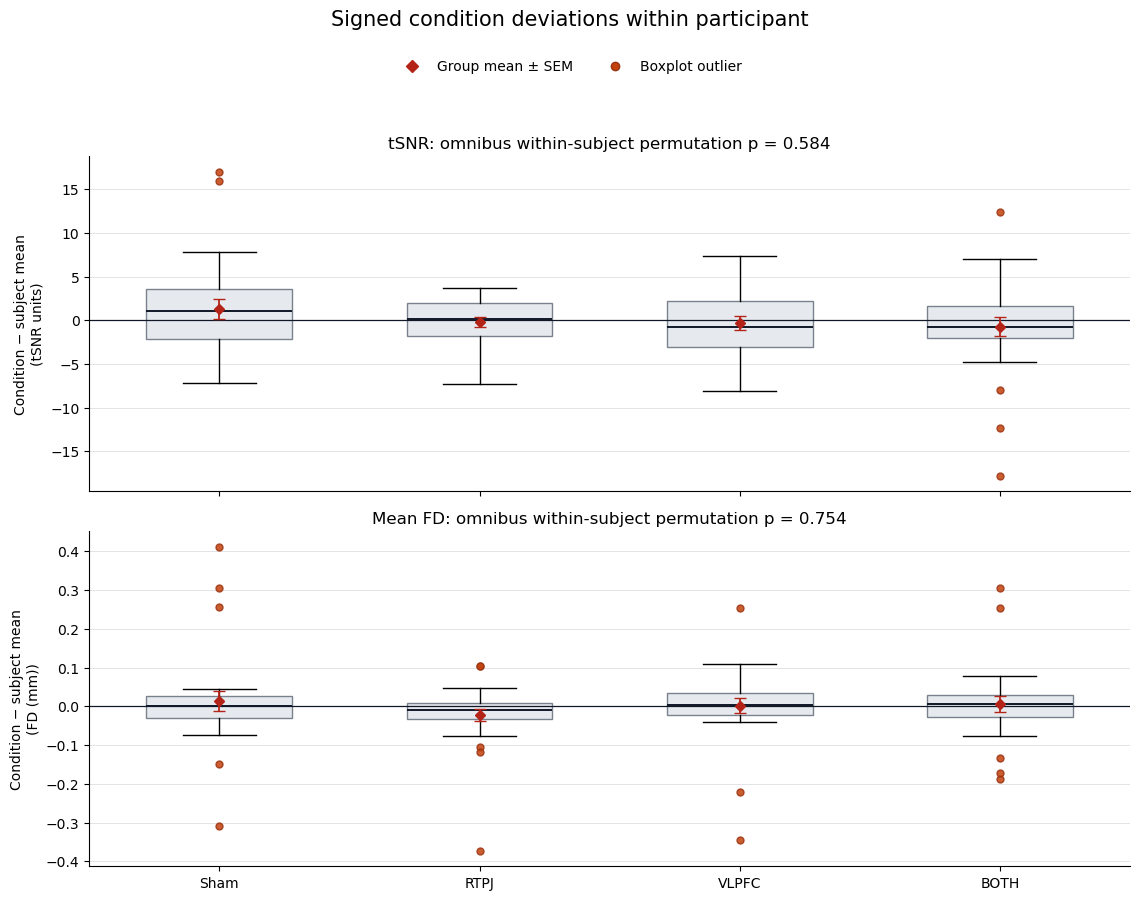

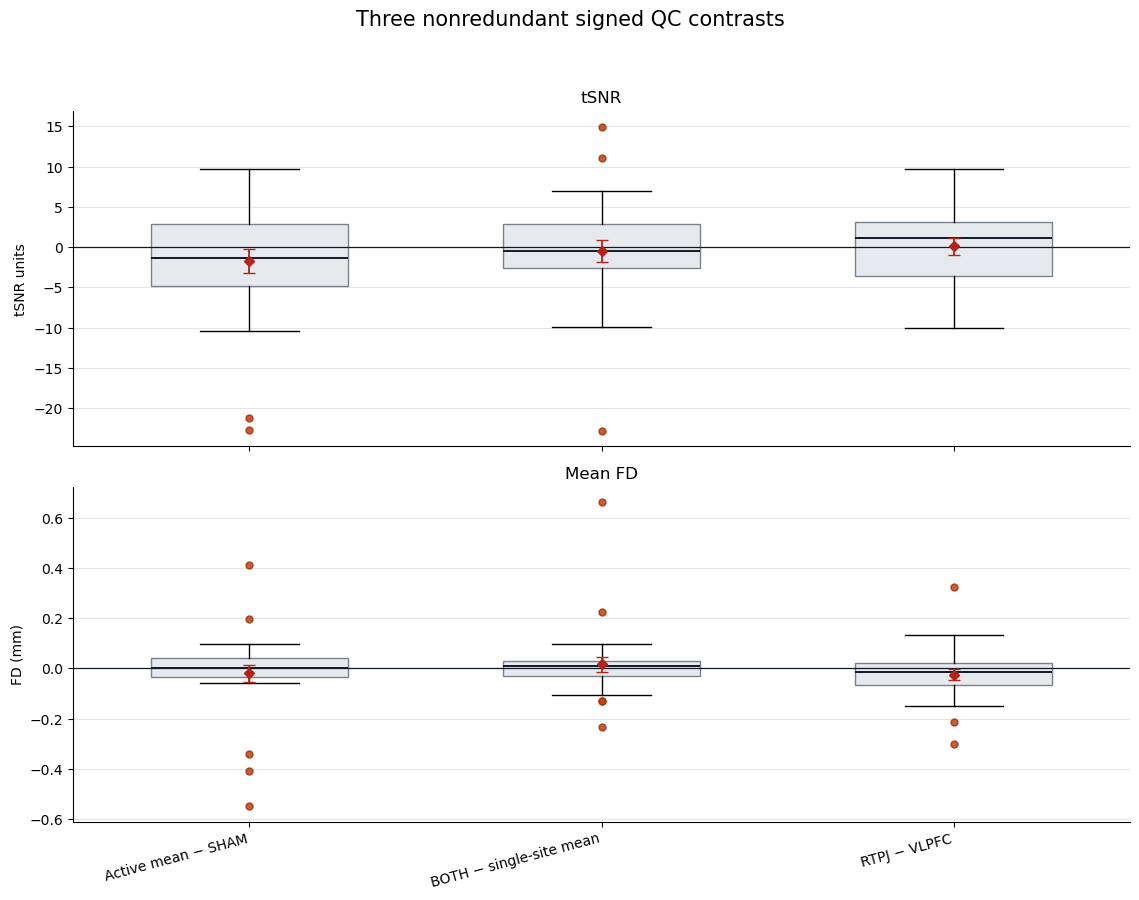

Metric,Orthogonal contrast,Mean,SEM,Positive N,Negative N
tSNR,Active mean − SHAM,-1.6873,1.4827,11,16
tSNR,BOTH − single-site mean,-0.4510,1.3413,10,17
tSNR,RTPJ − VLPFC,0.1240,1.0628,17,10
Mean FD,Active mean − SHAM,-0.0189,0.0342,14,13
Mean FD,BOTH − single-site mean,0.0165,0.0296,17,10
Mean FD,RTPJ − VLPFC,-0.0243,0.0222,12,15


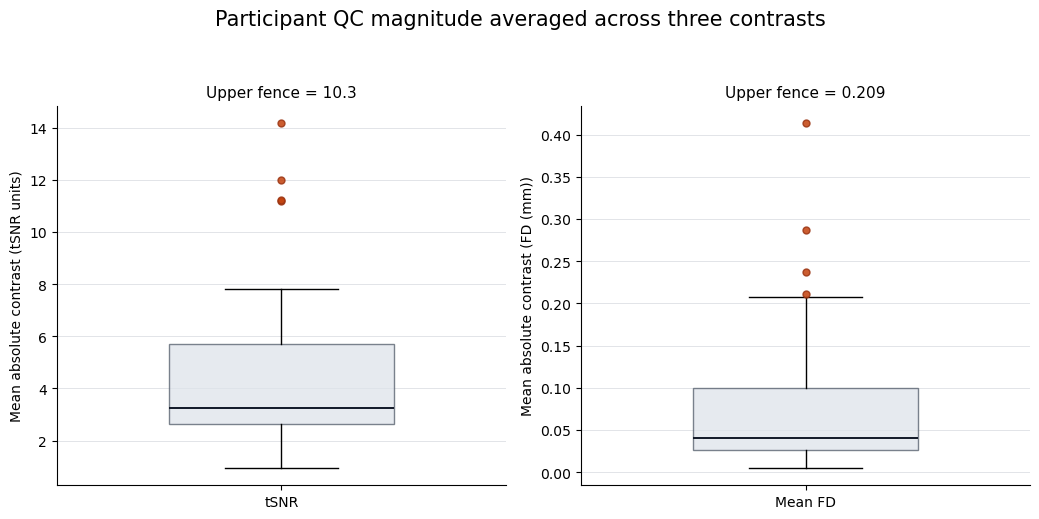

participant,active_mean_minus_sham_delta_tsnr,both_minus_mean_rtpj_vlpfc_delta_tsnr,rtpj_minus_vlpfc_delta_tsnr,mean_abs_delta_tsnr,tsnr_outlier,active_mean_minus_sham_delta_fd_mean,both_minus_mean_rtpj_vlpfc_delta_fd_mean,rtpj_minus_vlpfc_delta_fd_mean,mean_abs_delta_fd_mean,fd_mean_outlier,decision
sub-209,2.4057,5.4572,1.9309,3.2646,False,0.0970,-0.2351,-0.2999,0.2107,True,include
sub-218,-21.2042,-4.0885,8.2962,11.1963,True,0.4118,0.2259,-0.0750,0.2376,True,exclude
sub-222,8.0559,-8.2559,-5.2130,7.1749,False,-0.5494,0.6630,-0.0298,0.4141,True,include
sub-226,6.6155,-0.1145,-7.6048,4.7783,False,-0.4080,-0.1292,0.3243,0.2872,True,include
sub-230,-22.6951,-9.9682,-9.9352,14.1995,True,0.1980,0.0303,0.1312,0.1198,False,include
sub-236,-10.4450,-22.8446,-2.6902,11.9933,True,0.0259,0.0290,-0.0081,0.0210,False,include
sub-238,9.6638,14.9575,9.1168,11.2460,True,-0.3408,-0.1304,-0.1505,0.2072,False,include


### Reading these diagnostics

- Group condition-pattern tests: **tSNR p=0.584, Mean FD p=0.754**. Neither supports a consistent condition-linked QC pattern. These are not exclusion tests.
- The signed boxplots preserve direction; positive FD means more motion, while positive tSNR means better signal.
- The participant screen averages absolute magnitude across all three orthogonal contrasts, then applies the usual upper Tukey fence separately to tSNR and mean FD.
- Participants that are boxplot outliers for both metrics: **sub-218**. This identifies a QC exclusion candidate for a sensitivity analysis; it does not alter the frozen N=27 results above.

In [6]:
from matplotlib.lines import Line2D

QC_DIR = PROJECT_ROOT / 'derivatives' / 'qc'
qc_runs = pd.read_csv(QC_DIR / 'task-rest_mriqc_outliers.tsv', sep='\t')
QC_METRICS = {
    'tsnr': ('tSNR', 'tSNR units'),
    'fd_mean': ('Mean FD', 'FD (mm)'),
}
condition_sets = qc_runs.groupby('participant')['condition'].agg(lambda values: set(values.dropna()))
analysis_participants = sorted(
    condition_sets[condition_sets.apply(lambda values: values == set(CONDITION_ORDER))].index
)
qc_runs = qc_runs.loc[qc_runs['participant'].isin(analysis_participants)].copy()
qc_pivots = {
    metric: qc_runs.pivot(index='participant', columns='condition', values=metric).loc[
        analysis_participants, CONDITION_ORDER
    ]
    for metric in QC_METRICS
}
if any(table.isna().any().any() for table in qc_pivots.values()):
    raise ValueError('The N=27 QC table is missing a participant-condition value.')

qc_centered = {
    metric: table.subtract(table.mean(axis=1), axis=0)
    for metric, table in qc_pivots.items()
}

ORTHOGONAL_CONTRASTS = {
    'Active mean − SHAM': np.array([-1.0, 1 / 3, 1 / 3, 1 / 3]),
    'BOTH − single-site mean': np.array([0.0, -0.5, -0.5, 1.0]),
    'RTPJ − VLPFC': np.array([0.0, 1.0, -1.0, 0.0]),
}
qc_orthogonal = {
    metric: pd.DataFrame(
        {label: table.to_numpy() @ weights for label, weights in ORTHOGONAL_CONTRASTS.items()},
        index=table.index,
    )
    for metric, table in qc_pivots.items()
}

def condition_permutation_test(centered, n_permutations=20000, seed=20260623):
    values = centered.to_numpy()
    observed = float(np.square(values.mean(axis=0)).sum())
    rng = np.random.default_rng(seed)
    exceedances = 0
    for _ in range(n_permutations):
        orders = np.argsort(rng.random(values.shape), axis=1)
        permuted = np.take_along_axis(values, orders, axis=1)
        exceedances += float(np.square(permuted.mean(axis=0)).sum()) >= observed
    return observed, (exceedances + 1) / (n_permutations + 1)

omnibus = {
    metric: condition_permutation_test(table, seed=20260623 + index)
    for index, (metric, table) in enumerate(qc_centered.items())
}

mean_marker = {
    'marker': 'D', 'markersize': 5, 'markerfacecolor': '#B42318',
    'markeredgecolor': '#B42318', 'ecolor': '#B42318', 'elinewidth': 1.3,
    'capsize': 4, 'linestyle': 'none', 'zorder': 5,
}
flier_style = {
    'marker': 'o', 'markerfacecolor': '#C2410C', 'markeredgecolor': '#9A3412',
    'markersize': 5, 'alpha': 0.85,
}

fig, axes = plt.subplots(2, 1, figsize=(11.5, 9), sharex=True)
for axis, (metric, (label, unit)) in zip(axes, QC_METRICS.items()):
    table = qc_centered[metric]
    distributions = [table[condition].to_numpy() for condition in CONDITION_ORDER]
    boxes = axis.boxplot(
        distributions, positions=range(1, 5), widths=0.56, whis=1.5,
        showfliers=True, patch_artist=True, flierprops=flier_style,
        medianprops={'color': '#111827', 'linewidth': 1.4},
    )
    for box in boxes['boxes']:
        box.set(facecolor='#DDE3EA', edgecolor='#4B5563', alpha=0.72)
    for position, values in enumerate(distributions, start=1):
        axis.errorbar(
            position, values.mean(), yerr=values.std(ddof=1) / np.sqrt(len(values)),
            **mean_marker,
        )
    axis.axhline(0, color='#111827', linewidth=0.9)
    axis.set_ylabel(f'Condition − subject mean\n({unit})')
    axis.set_title(f'{label}: omnibus within-subject permutation p = {omnibus[metric][1]:.3f}', fontsize=12)
    axis.grid(axis='y', color='#D1D5DB', linewidth=0.7, alpha=0.65)
    axis.spines[['top', 'right']].set_visible(False)
axes[-1].set_xticks(range(1, 5), CONDITION_LABELS)
fig.suptitle('Signed condition deviations within participant', fontsize=15, y=0.995)
fig.legend(
    handles=[
        Line2D([0], [0], marker='D', color='#B42318', markerfacecolor='#B42318', linestyle='none', label='Group mean ± SEM'),
        Line2D([0], [0], marker='o', color='none', markerfacecolor='#C2410C', markeredgecolor='#9A3412', linestyle='none', label='Boxplot outlier'),
    ],
    loc='upper center', bbox_to_anchor=(0.5, 0.953), ncol=2, frameon=False,
)
fig.tight_layout(rect=(0, 0, 1, 0.91))
display(fig)
plt.close(fig)

fig, axes = plt.subplots(2, 1, figsize=(11.5, 9), sharex=True)
contrast_rows = []
for axis, (metric, (label, unit)) in zip(axes, QC_METRICS.items()):
    table = qc_orthogonal[metric]
    distributions = [table[column].to_numpy() for column in ORTHOGONAL_CONTRASTS]
    boxes = axis.boxplot(
        distributions, positions=range(1, 4), widths=0.56, whis=1.5,
        showfliers=True, patch_artist=True, flierprops=flier_style,
        medianprops={'color': '#111827', 'linewidth': 1.4},
    )
    for box in boxes['boxes']:
        box.set(facecolor='#DDE3EA', edgecolor='#4B5563', alpha=0.72)
    for position, (contrast, values) in enumerate(zip(ORTHOGONAL_CONTRASTS, distributions), start=1):
        axis.errorbar(
            position, values.mean(), yerr=values.std(ddof=1) / np.sqrt(len(values)),
            **mean_marker,
        )
        contrast_rows.append({
            'Metric': label,
            'Orthogonal contrast': contrast,
            'Mean': values.mean(),
            'SEM': values.std(ddof=1) / np.sqrt(len(values)),
            'Positive N': int((values > 0).sum()),
            'Negative N': int((values < 0).sum()),
        })
    axis.axhline(0, color='#111827', linewidth=0.9)
    axis.set_ylabel(unit)
    axis.set_title(label, fontsize=12)
    axis.grid(axis='y', color='#D1D5DB', linewidth=0.7, alpha=0.65)
    axis.spines[['top', 'right']].set_visible(False)
axes[-1].set_xticks(range(1, 4), list(ORTHOGONAL_CONTRASTS), rotation=15, ha='right')
fig.suptitle('Three nonredundant signed QC contrasts', fontsize=15, y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.96))
display(fig)
plt.close(fig)
display(pd.DataFrame(contrast_rows).style.format({'Mean': '{:.4f}', 'SEM': '{:.4f}'}).hide(axis='index'))

qc_decisions = pd.read_csv(QC_DIR / 'task-rest_qc_exclusions.tsv', sep='\t')
qc_bounds = pd.read_csv(QC_DIR / 'task-rest_qc_contrast_average_bounds.tsv', sep='\t').set_index('metric')
score_columns = {
    'tsnr': 'mean_abs_delta_tsnr',
    'fd_mean': 'mean_abs_delta_fd_mean',
}
fig, axes = plt.subplots(1, 2, figsize=(10.5, 5.2))
for axis, (metric, (label, unit)) in zip(axes, QC_METRICS.items()):
    values = qc_decisions[score_columns[metric]].to_numpy()
    fence = float(qc_bounds.loc[metric, 'upper_fence'])
    boxes = axis.boxplot(
        [values], positions=[1], widths=0.5, whis=1.5,
        showfliers=True, patch_artist=True, flierprops=flier_style,
        medianprops={'color': '#111827', 'linewidth': 1.4},
    )
    boxes['boxes'][0].set(facecolor='#DDE3EA', edgecolor='#4B5563', alpha=0.72)
    axis.set_xticks([1], [label])
    axis.set_ylabel(f'Mean absolute contrast ({unit})')
    axis.set_title(f'Upper fence = {fence:.3g}', fontsize=11)
    axis.grid(axis='y', color='#D1D5DB', linewidth=0.7, alpha=0.65)
    axis.spines[['top', 'right']].set_visible(False)
fig.suptitle('Participant QC magnitude averaged across three contrasts', fontsize=15, y=0.99)
fig.tight_layout(rect=(0, 0, 1, 0.94))
display(fig)
plt.close(fig)

review_columns = [
    'participant',
    'active_mean_minus_sham_delta_tsnr',
    'both_minus_mean_rtpj_vlpfc_delta_tsnr',
    'rtpj_minus_vlpfc_delta_tsnr',
    'mean_abs_delta_tsnr', 'tsnr_outlier',
    'active_mean_minus_sham_delta_fd_mean',
    'both_minus_mean_rtpj_vlpfc_delta_fd_mean',
    'rtpj_minus_vlpfc_delta_fd_mean',
    'mean_abs_delta_fd_mean', 'fd_mean_outlier',
    'decision',
]
review = qc_decisions.loc[qc_decisions['n_metric_outliers'] > 0, review_columns].copy()
display(review.style.format({
    column: '{:.4f}'
    for column in review.columns
    if '_delta_' in column or column.startswith('mean_abs_')
}).hide(axis='index'))

excluded = qc_decisions.loc[qc_decisions['decision'] == 'exclude', 'participant'].tolist()
omnibus_text = ', '.join(
    f"{QC_METRICS[metric][0]} p={result[1]:.3f}" for metric, result in omnibus.items()
)
display(Markdown(
    '### Reading these diagnostics\n\n'
    f'- Group condition-pattern tests: **{omnibus_text}**. Neither supports a consistent condition-linked QC pattern. These are not exclusion tests.\n'
    '- The signed boxplots preserve direction; positive FD means more motion, while positive tSNR means better signal.\n'
    '- The participant screen averages absolute magnitude across all three orthogonal contrasts, then applies the usual upper Tukey fence separately to tSNR and mean FD.\n'
    f"- Participants that are boxplot outliers for both metrics: **{', '.join(excluded) or 'none'}**. This identifies a QC exclusion candidate for a sensitivity analysis; it does not alter the frozen N=27 results above."
))


## 7. Interpretation notes

The bars show mean stage-2 beta ± SEM extracted from each significant cluster. Because each displayed region was selected from the same group contrast, these values are a descriptive visualization of the result, not an independent ROI test. Cluster-extent corrected p-values control spatial inference within each randomise job. Across jobs, each reported network/contrast is treated as an individual hypothesis rather than as evidence for the disjunctive claim that at least one effect exists somewhere. Under Rubin's inference-based account, that distinction determines whether an across-job alpha adjustment is relevant. Confirmatory ROI inference requires an independently defined mask or held-out data.
